### Data

In [7]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNetCV, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA


In [ ]:
from sklearn.model_selection import cross_val_score


In [35]:
file_path = "energydata_complete.csv"
df = pd.read_csv(file_path)
# Convert date column to datetime format (instead of object)
df['date'] = pd.to_datetime(df['date'])

# set date as index because we have 10min intervals i.e uniqueness 
df.set_index('date', inplace=True) 

# To analyse temporal tendencies and have meaningful features, we create the hour, day of the week, month and year features from the date index
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

X = df.drop(columns=['Appliances', 'rv1', 'rv2'])  
y = df['Appliances']

# Let's encode categorical variables using one-hot encoding
X = pd.get_dummies(X, columns=['month', 'day_of_week', 'hour'], drop_first=True)

# Define prefixes for dummy categorical features
dummy_prefixes = ['hour_', 'day_of_week_', 'month_']

# Get numeric feature columns (exclude dummy categorical features)
numeric_cols = [col for col in X.columns if not any(col.startswith(prefix) for prefix in dummy_prefixes)]



In [36]:
# Let's normalize the data to avoid bias towards any feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [37]:
# Create dataframes using only numeric features
X_df = pd.DataFrame(X, columns=X.columns)[numeric_cols]
X_df_scaled = pd.DataFrame(X_scaled, columns=X.columns)[numeric_cols]

### Reduce the complexity model

##### Heatmap Analysis

Very strong correlations:
- **Indoor temperatures (T1 with T2, T3, T4, T5, T7, T8, T9)** *NOT T6*:
Indoor temperatures (T1–T9) explain the same phenomenon, it is normal that they evolve similarly.
- **Between T9 and T3, T4, T5, T7, T8**:
T9 is the master bedroom; perhaps the heating is based on the temperature in this room.
- **Between T_out and T6**: T_out represents the general outdoor temperature, while T6 is the temperature outside, on the north side of the building. It makes sense that they behave similarly.
- **RH_6 with T9, T8, T7, T6, T4**:
- **Between the variable "month" and indoor temperatures (T1, T3, T4, T5, T7, T8, T9)**: Indoor temperatures (T1, T3, T4, etc.) vary depending on the seasons (winter versus summer).
- **Very strong negative correlation with RH_6**: For example, in winter, the outdoor air is often drier (decrease in RH_6), whereas in autumn or spring, the relative humidity may be higher. Thus, the monthly evolution of climatic conditions results in an inverse relationship between "month" and RH_6.

We could therefore consider dimensionality reduction for temperatures and humidities since they exhibit similar trends.
- **Aggregation by mean**: Create a variable, the mean of temperatures and the mean of humidities, which captures the overall trend.
- **PCA**: Extract the first or the first two principal components of indoor temperatures and humidities. Start with one component and then add a second to see if performance improves.

In [103]:
# Define column names for temperature and humidity features with more correlation
temperature_cols = ['T1', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']
humidity_cols = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_9']

#### PCA for temperatures and humidity, print the explained variance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extract the scaled subsets for temperature and humidity
X_temp = X[temperature_cols]
X_hum = X[humidity_cols]

# If X is scaled into X_scaled already, extract the same columns from it
X_temp_scaled = X_scaled[:, [X.columns.get_loc(col) for col in temperature_cols]]
X_hum_scaled = X_scaled[:, [X.columns.get_loc(col) for col in humidity_cols]]

# PCA for Temperature features
pca_temp = PCA()
pca_temp.fit(X_temp_scaled)

# Explained variance ratio
explained_variance_temp = pca_temp.explained_variance_ratio_

#variance explained by each component
for i, var in enumerate(explained_variance_temp):
    print(f"PC{i+1} (Temp): {var:.4f} ({np.cumsum(explained_variance_temp)[i]*100:.2f}% cumulative)")

# Project the original data into one dimention space
X_temp_pca = pca_temp.transform(X_temp_scaled)
temp_PC1 = X_temp_pca[:, :1] # 1 PC enough, it explains 88% of the variance


# PCA for Humidity features
pca_hum = PCA()
pca_hum.fit(X_hum_scaled)

# Explained variance ratio
explained_variance_hum = pca_hum.explained_variance_ratio_

#variance explained by each component
print()
for i, var in enumerate(explained_variance_hum):
    print(f"PC{i+1} (Hum): {var:.4f} ({np.cumsum(explained_variance_hum)[i]*100:.2f}% cumulative)")

# Transform the original data: the 7 columns transformed into 2 columns (projection in a 2D space)
X_hum_pca = pca_hum.transform(X_hum_scaled)
hum_PC2 = X_hum_pca[:, :2] # PC2 explains 86% of the variance



PC1 (Temp): 0.8854 (88.54% cumulative)
PC2 (Temp): 0.0372 (92.26% cumulative)
PC3 (Temp): 0.0250 (94.76% cumulative)
PC4 (Temp): 0.0215 (96.90% cumulative)
PC5 (Temp): 0.0154 (98.45% cumulative)
PC6 (Temp): 0.0105 (99.49% cumulative)
PC7 (Temp): 0.0051 (100.00% cumulative)

PC1 (Hum): 0.7375 (73.75% cumulative)
PC2 (Hum): 0.1240 (86.14% cumulative)
PC3 (Hum): 0.0599 (92.13% cumulative)
PC4 (Hum): 0.0315 (95.29% cumulative)
PC5 (Hum): 0.0215 (97.44% cumulative)
PC6 (Hum): 0.0152 (98.96% cumulative)
PC7 (Hum): 0.0104 (100.00% cumulative)


#### Replace temp and humidity columns by PCA values and see the Linear regression performance

In [68]:
# Create a DataFrame from X_scaled using the original column names
df_reduced = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Replace temperature columns with temp_PC1
df_reduced['temp_PC1'] = temp_PC1.flatten()
df_reduced.drop(columns=temperature_cols, inplace=True)

# Replace humidity columns with hum_PC2 (2 principal components)
df_reduced['hum_PC1'] = hum_PC2[:, 0]
df_reduced['hum_PC2'] = hum_PC2[:, 1]
df_reduced.drop(columns=humidity_cols, inplace=True)

# Display the reduced DataFrame
#df_reduced.head()
df_reduced.shape



(19735, 47)

In [99]:
def evaluate_regression(model, X_train, y_train, X_test, y_test):
    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Évaluation - Train
    r2_train = r2_score(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)

    # Évaluation - Test
    r2_test = r2_score(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    # Affichage des métriques
    print("Évaluation sur les données d'entraînement :")
    print(f"  R² : {r2_train:.3f}")
    print(f"  MSE : {mse_train:.3f}")
    print(f"  MAE : {mae_train:.3f}")
    print("\nÉvaluation sur les données de test :")
    print(f"  R² : {r2_test:.3f}")
    print(f"  MSE : {mse_test:.3f}")
    print(f"  MAE : {mae_test:.3f}")

    # Tracer les résultats
    plt.figure(figsize=(18, 5))

    # Plot 1 : Prédictions vs Réel (train)
    plt.subplot(1, 3, 1)
    plt.scatter(y_train, y_train_pred, alpha=0.7, color='blue')
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--')
    plt.xlabel("Valeurs réelles (Train)")
    plt.ylabel("Prédictions")
    plt.title("Prédictions vs Réel (Train)")

    # Plot 2 : Prédictions vs Réel (test)
    plt.subplot(1, 3, 2)
    plt.scatter(y_test, y_test_pred, alpha=0.7, color='green')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
    plt.xlabel("Valeurs réelles (Test)")
    plt.ylabel("Prédictions")
    plt.title("Prédictions vs Réel (Test)")

    # Plot 3 : Résidus (test)
    plt.subplot(1, 3, 3)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.7, color='red')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel("Prédictions")
    plt.ylabel("Résidus")
    plt.title("Graphique des résidus (Test)")

    plt.tight_layout()
    plt.show()

In [ ]:
y = df['Appliances']

(19735,)

Évaluation sur les données d'entraînement :
  R² : 0.241
  MSE : 8073.393
  MAE : 50.926

Évaluation sur les données de test :
  R² : 0.232
  MSE : 7684.595
  MAE : 50.917


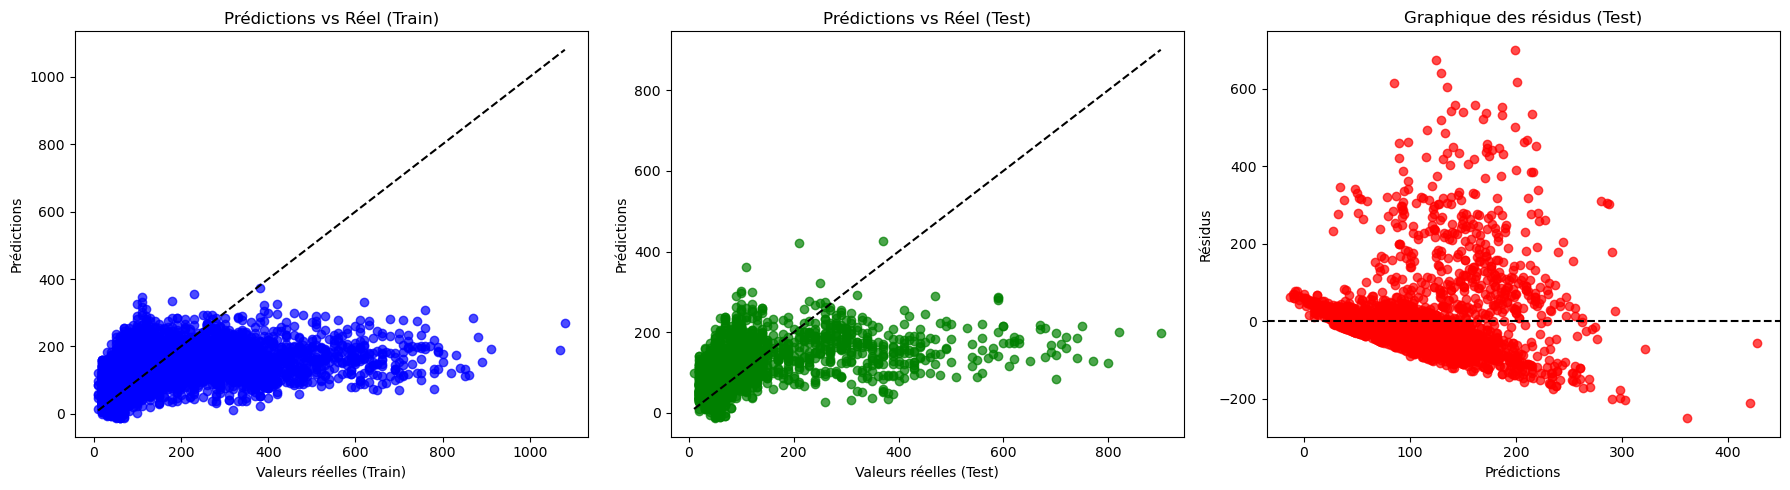

In [ ]:
# Split the data into training and testing sets ordered by time
# This is important because we are dealing with time series data
X_train, X_test, y_train, y_test = train_test_split(df_reduced, y, test_size=0.2, random_state=42)

# Fit a Linear Regression model to the pca-reduced data
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
evaluate_regression(model, X_train, y_train, X_test, y_test)

#### Replace temp and humidity columns by mean values and see the Linear regression performance

Évaluation sur les données d'entraînement :
  R² : 0.188
  MSE : 8639.916
  MAE : 52.659

Évaluation sur les données de test :
  R² : 0.181
  MSE : 8199.600
  MAE : 52.525


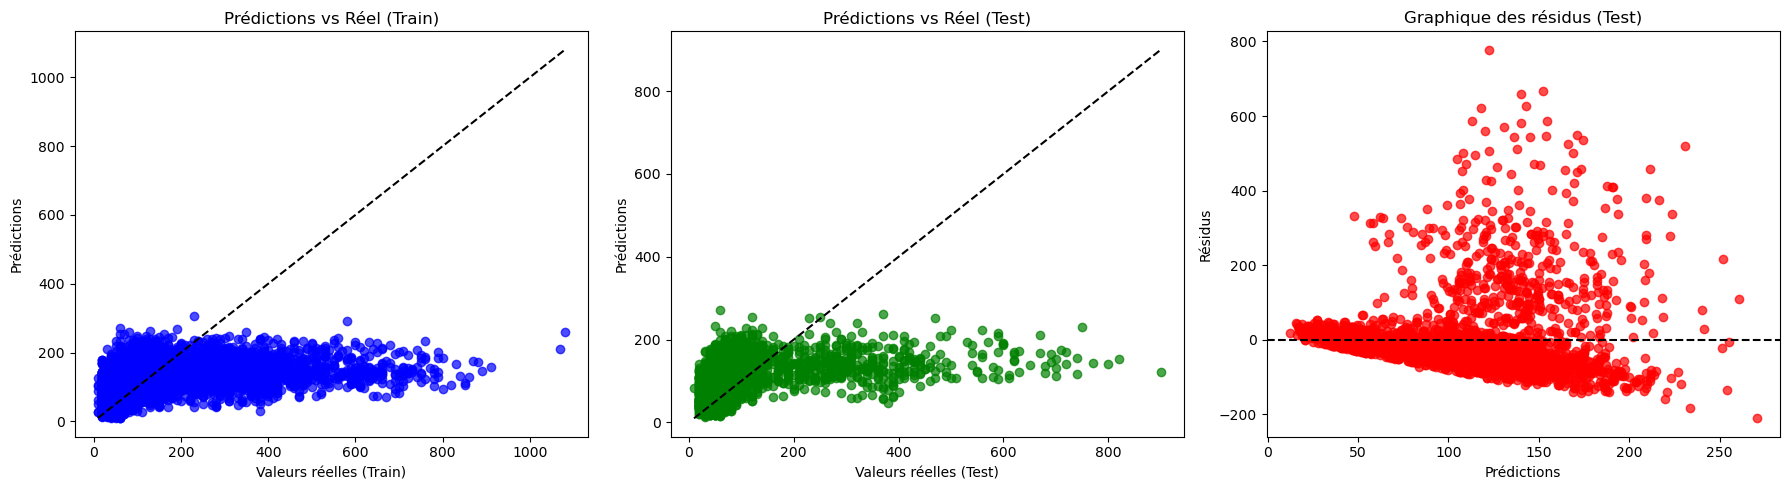

In [105]:
# Create a DataFrame from X_scaled using the original column names
df_reduced_mean = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Replace temperature columns with the meaned temperature from temperature_cols
meaned_temp = df_reduced_mean[temperature_cols].mean(axis=1)
df_reduced_mean['meaned_temp'] = meaned_temp
df_reduced_mean.drop(columns=temperature_cols, inplace=True)
# Replace humidity columns with the meaned humidity from humidity_cols
meaned_hum = df_reduced_mean[humidity_cols].mean(axis=1)
df_reduced_mean['meaned_hum'] = meaned_hum
df_reduced_mean.drop(columns=humidity_cols, inplace=True)

# Display the reduced DataFrame
#df_reduced_mean.head()
X_train, X_test, y_train, y_test = train_test_split(df_reduced_mean, y, test_size=0.2, random_state=42)

# Fit a Linear Regression model to the pca-reduced data
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
evaluate_regression(model, X_train, y_train, X_test, y_test)

### Penalisation

A penalty on the parameters of linear regression does not seem like a good option because simplifying the model has deteriorated its performance. Therefore, it is likely not in our interest to nullify some coefficients to reduce complexity, meaning that  <span style="color: #FFD580;">L1 regularization (Lasso) is probably not a good idea.</span>

On the other hand, we are far from overfitting, so redistributing the weights with <span style="color: #FFD580;">L2 regularization (Ridge) also does not seem to be the best option</span>  in this case. We will likely need to move to more complex models to better explain the relationship between our features and the target variable, "Appliances."


In [107]:
def evaluate_linear_model(model, X_test, y_test, feature_names=None):
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Print the evaluation metrics
    print(f'MAE: {mae:.2f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R^2: {r2:.2f}')
    
    # Calculate residuals
    residuals = y_pred - y_test

    # Determine number of subplots (add one if feature importances are available)
    if hasattr(model, "coef_") and feature_names is not None:
        n_plots = 5
        # Create a grid of 2 rows x 3 columns and use the first 5 axes.
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        ax1, ax2, ax3, ax4, ax5 = axes.ravel()[:5]
    else:
        n_plots = 4
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        ax1, ax2, ax3, ax4 = axes.ravel()

    # Plot 1: Predicted vs Actual (Line Plot)
    ax1.plot(y_test, label='Actual', color='blue', alpha=0.5)
    ax1.plot(y_pred, label='Predicted', color='orange', alpha=0.5)
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Target Value')
    ax1.set_title('Predicted vs Actual (Line Plot)')
    ax1.legend()

    # Plot 2: Predicted vs Actual (Scatter Plot)
    ax2.scatter(y_test, y_pred, alpha=0.5)
    ax2.set_xlabel('Actual Values')
    ax2.set_ylabel('Predicted Values')
    ax2.set_title('Predicted vs Actual (Scatter)')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

    # Plot 3: Residuals vs Predicted Values
    ax3.scatter(y_pred, residuals, alpha=0.5)
    ax3.axhline(0, color='red', linestyle='--')
    ax3.set_xlabel('Predicted Values')
    ax3.set_ylabel('Residuals')
    ax3.set_title('Residuals vs Predicted')

    # Plot 4: Distribution of Residuals (Histogram)
    ax4.hist(residuals, bins=30, alpha=0.7, color='blue')
    ax4.axvline(0, color='red', linestyle='--')
    ax4.set_xlabel('Residuals')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Residuals Distribution')

    # Plot 5: Feature Importances (if available)
    if hasattr(model, "coef_") and feature_names is not None:
        importances = np.ravel(model.coef_)
        indices = np.argsort(np.abs(importances))[::-1]
        ax5.bar(range(len(importances)), importances[indices], align='center')
        ax5.set_xticks(range(len(importances)))
        ax5.set_xticklabels(np.array(feature_names)[indices], rotation=90)
        ax5.set_xlim([-1, len(importances)])
        ax5.set_title('Feature Importances')

    plt.tight_layout()
    plt.show()
    

MAE: 0.50
MSE: 0.73
RMSE: 0.86
R^2: 0.23


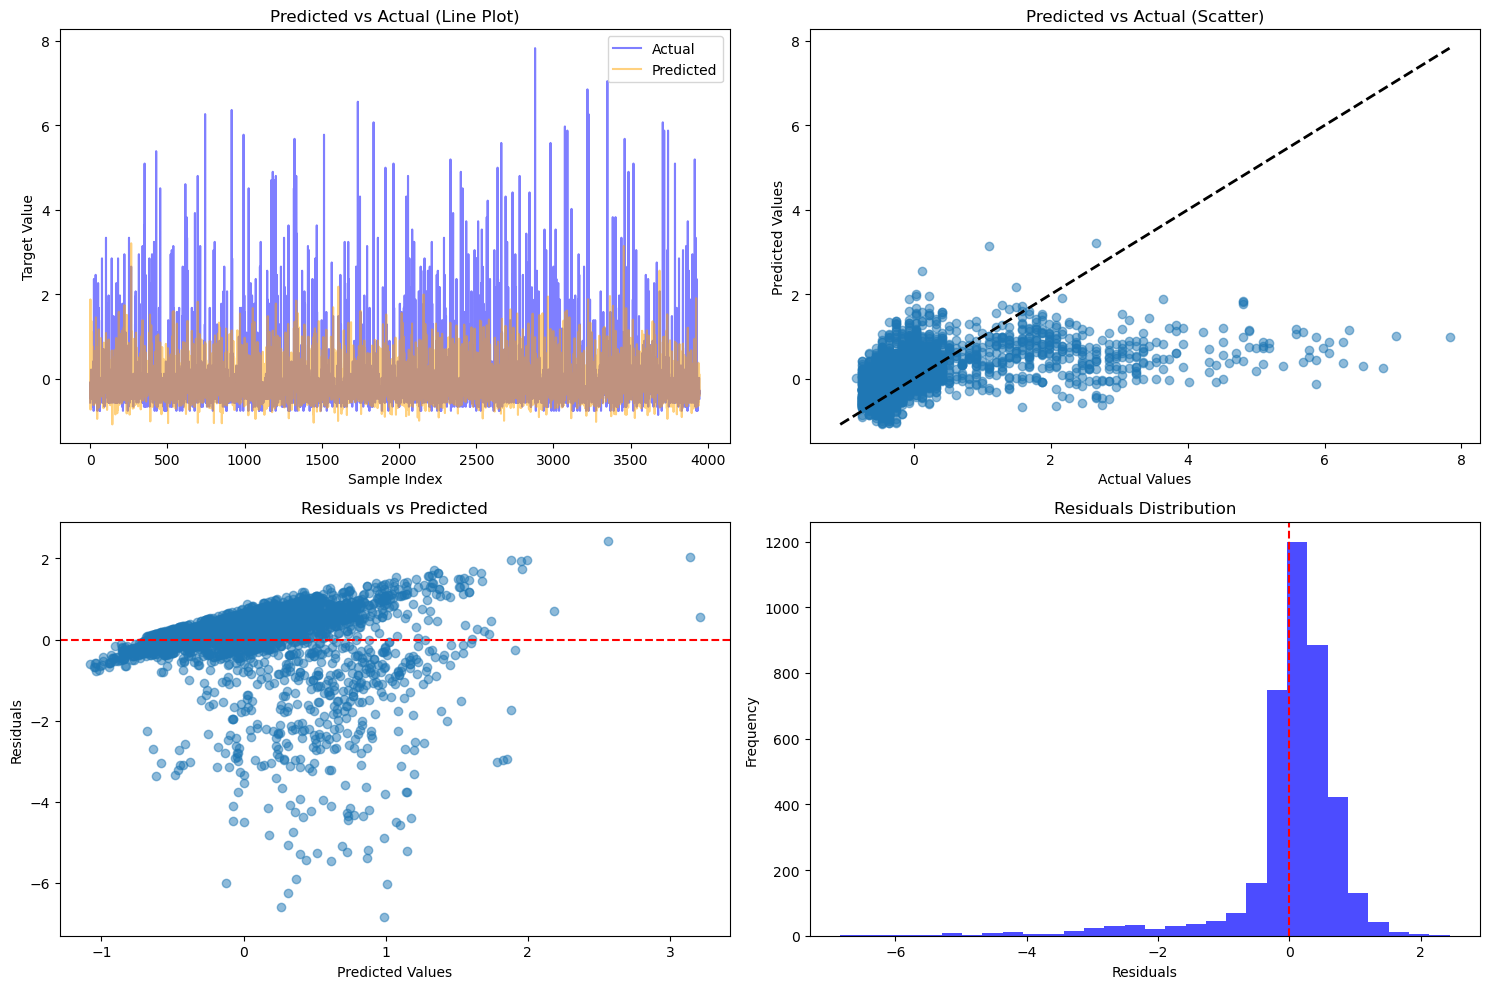

In [ ]:
from sklearn.linear_model import Ridge

# train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Initialize Ridge regression model
ridge_model = Ridge(alpha=2)  # You can tune the alpha parameter for regularization strength

# Fit the model to the training data
ridge_model.fit(X_train, y_train)

# Evaluate the model
evaluate_linear_model(ridge_model, X_test, y_test)

### Comparison of Ridge and Non-Penalized Performances

| Metric       | Ridge Performance | Non-Penalized Performance |
|--------------|-------------------|---------------------------|
| **MAE**      | 0.50              | 0.50                      |
| **MSE**      | 0.73              | 0.77                      |
| **RMSE**     | 0.86              | 0.88                      |
| **R²**       | 0.23              | 0.24                      |

The improvement is negligible. Let's explore more complex models.